# Bank Marketing - Exploratory Data Analysis

**Data4950 Week 6 Demo**

## What we will cover

1. Load and inspect data
2. Check data quality
3. Analyze target variable (class imbalance)
4. Explore numerical features
5. Explore categorical features
6. Find correlations with target
7. Detect data leakage

In [1]:
## import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## setting for plots
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)


print('All libraries loaded!')

All libraries loaded!


## 1. Load the Data

**Business Context:** A Portuguese bank ran phone campaigns to sell term deposits.  
We want to predict whether a client will subscribe (yes/no).

Source: [UCI Bank Marketing Dataset](https://archive.ics.uci.edu/ml/datasets/Bank+Marketing)

Poutcome (previous campaign outcome)

Default: Clients with no credit default history

In [2]:
## load Bank Marketing dataset
df= pd.read_csv('../data/raw/bank-additional-full.csv')
df

,"age;""job"";""marital"";""education"";""default"";""housing"";""loan"";""contact"";""month"";""day_of_week"";""duration"";""campaign"";""pdays"";""previous"";""poutcome"";""emp.var.rate"";""cons.price.idx"";""cons.conf.idx"";""euribor3m"";""nr.employed"";""y"""
0,"56;""housemaid"";""married"";""basic.4y"";""no"";""no"";..."
1,"57;""services"";""married"";""high.school"";""unknown..."
2,"37;""services"";""married"";""high.school"";""no"";""ye..."
3,"40;""admin."";""married"";""basic.6y"";""no"";""no"";""no..."
4,"56;""services"";""married"";""high.school"";""no"";""no..."
...,...
41183,"73;""retired"";""married"";""professional.course"";""..."
41184,"46;""blue-collar"";""married"";""professional.cours..."
41185,"56;""retired"";""married"";""university.degree"";""no..."
41186,"44;""technician"";""married"";""professional.course..."


In [3]:
## TODO: load Bank Marketing dataset (semicolon separated)




,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,334,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,383,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,189,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,442,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [4]:
## check data quality

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [5]:
# data shape

df.shape

(41188, 21)

In [6]:
# print data shape

print(f' Data loaded: {df.shape[0]:,} rows x {df.shape[1]:,} columns')

 Data loaded: 41,188 rows x 21 columns


In [7]:
## first 5 rows by default

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [8]:
## last 5 rows
df.tail(5)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,334,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,383,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,189,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,442,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41187,74,retired,married,professional.course,no,yes,no,cellular,nov,fri,239,3,999,1,failure,-1.1,94.767,-50.8,1.028,4963.6,no


In [9]:
## random 4 rows
df.sample(4)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
27798,32,management,single,university.degree,no,yes,no,telephone,mar,tue,230,2,999,0,nonexistent,-1.8,92.843,-50.0,1.687,5099.1,no
16482,28,management,single,university.degree,no,yes,no,cellular,jul,wed,35,9,999,0,nonexistent,1.4,93.918,-42.7,4.963,5228.1,no
8137,60,unknown,married,basic.6y,unknown,no,no,telephone,jun,tue,104,7,999,0,nonexistent,1.4,94.465,-41.8,4.864,5228.1,no
1627,36,services,married,basic.6y,no,no,no,telephone,may,fri,296,3,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no


## 2. Data Quality Check

In [10]:
## data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [11]:
## data types
df.dtypes

age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

In [12]:
## TODO: check missing values

print(f'Missing values: {df.isnull().sum().sum()}')

Missing values: 0


In [13]:
## check if duplicate rows

print(f'Duplicate rows: {df.duplicated().sum()}')

Duplicate rows: 12


In [14]:
## TODO: check for 'unknown' values (this dataset uses 'unknown' instead of NaN) and compute the ratio of 'unknown' values



,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,nonexistent,no
1,services,married,high.school,unknown,no,no,telephone,may,mon,nonexistent,no
2,services,married,high.school,no,yes,no,telephone,may,mon,nonexistent,no
3,admin.,married,basic.6y,no,no,no,telephone,may,mon,nonexistent,no
4,services,married,high.school,no,no,yes,telephone,may,mon,nonexistent,no
...,...,...,...,...,...,...,...,...,...,...,...
41183,retired,married,professional.course,no,yes,no,cellular,nov,fri,nonexistent,yes
41184,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,nonexistent,no
41185,retired,married,university.degree,no,yes,no,cellular,nov,fri,nonexistent,no
41186,technician,married,professional.course,no,no,no,cellular,nov,fri,nonexistent,yes


job: 330 unknowns (0.8%)
marital: 80 unknowns (0.2%)
education: 1731 unknowns (4.2%)
default: 8597 unknowns (20.9%)
housing: 990 unknowns (2.4%)
loan: 990 unknowns (2.4%)


In [16]:
# summary statistics
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


## 3. Target Variable Analysis

Our target is `y` — did the client subscribe to a term deposit? (yes/no)  
This is a **classification** problem (not regression).

<Axes: >

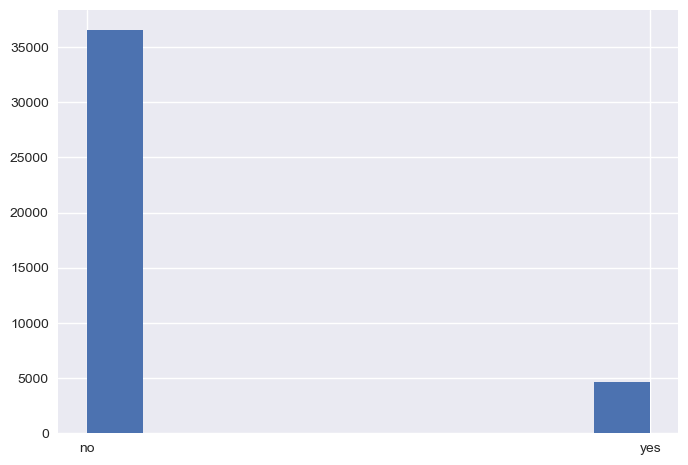

In [17]:
## histogram plot of target variable

df['y'].hist()

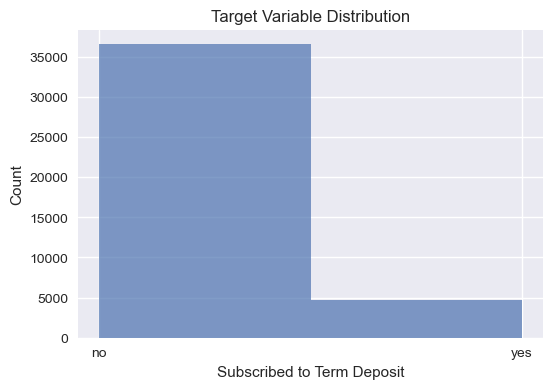

In [18]:
plt.figure(figsize=(6,4))
plt.hist(df['y'], bins=2,alpha=0.7)
plt.xlabel('Subscribed to Term Deposit')
plt.ylabel('Count')
plt.title('Target Variable Distribution')
plt.show()

In [19]:
## target variable value counts
counts = df['y'].value_counts()
counts

y
no     36548
yes     4640
Name: count, dtype: int64

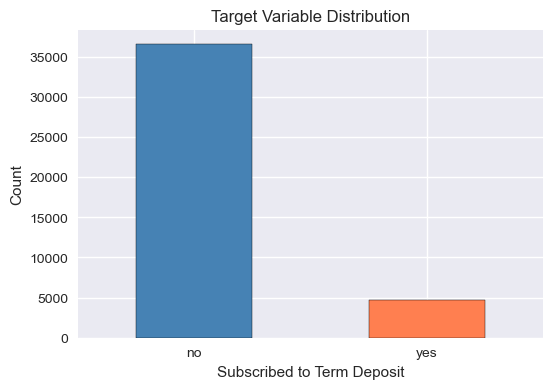

In [20]:
## bar chart of target variable

plt.figure(figsize=(6,4))
counts.plot(kind='bar',color=['steelblue', 'coral'], edgecolor='black')
plt.xlabel('Subscribed to Term Deposit')
plt.ylabel('Count')
plt.title('Target Variable Distribution')
plt.xticks(rotation=0)
plt.show()

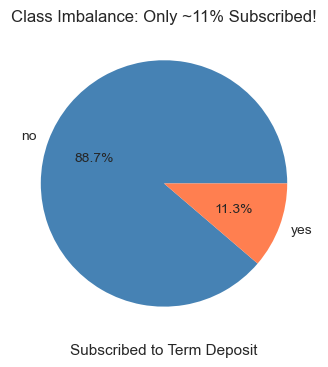

In [21]:
# pie chart to show imbalance

plt.figure(figsize=(6,4))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%',colors=['steelblue', 'coral'])
plt.xlabel('Subscribed to Term Deposit')
plt.ylabel('')
plt.title('Class Imbalance: Only ~11% Subscribed!')
plt.show()

## 4. Explore Numerical Features

In [22]:
df.dtypes

age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

In [23]:
features = df.columns
features

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [24]:
## get numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f'numerical columns ({len(numerical_cols)}):')
numerical_cols

numerical columns (10):


['age',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed']

In [25]:
## summary statistics for numerical features
df[numerical_cols].describe().round(2)

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00
mean,40.02,258.29,2.57,962.48,0.17,0.08,93.58,-40.50,3.62,5167.04
std,10.42,259.28,2.77,186.91,0.49,1.57,0.58,4.63,1.73,72.25
min,17.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,32.00,102.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,180.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,319.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,98.00,4918.00,56.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10


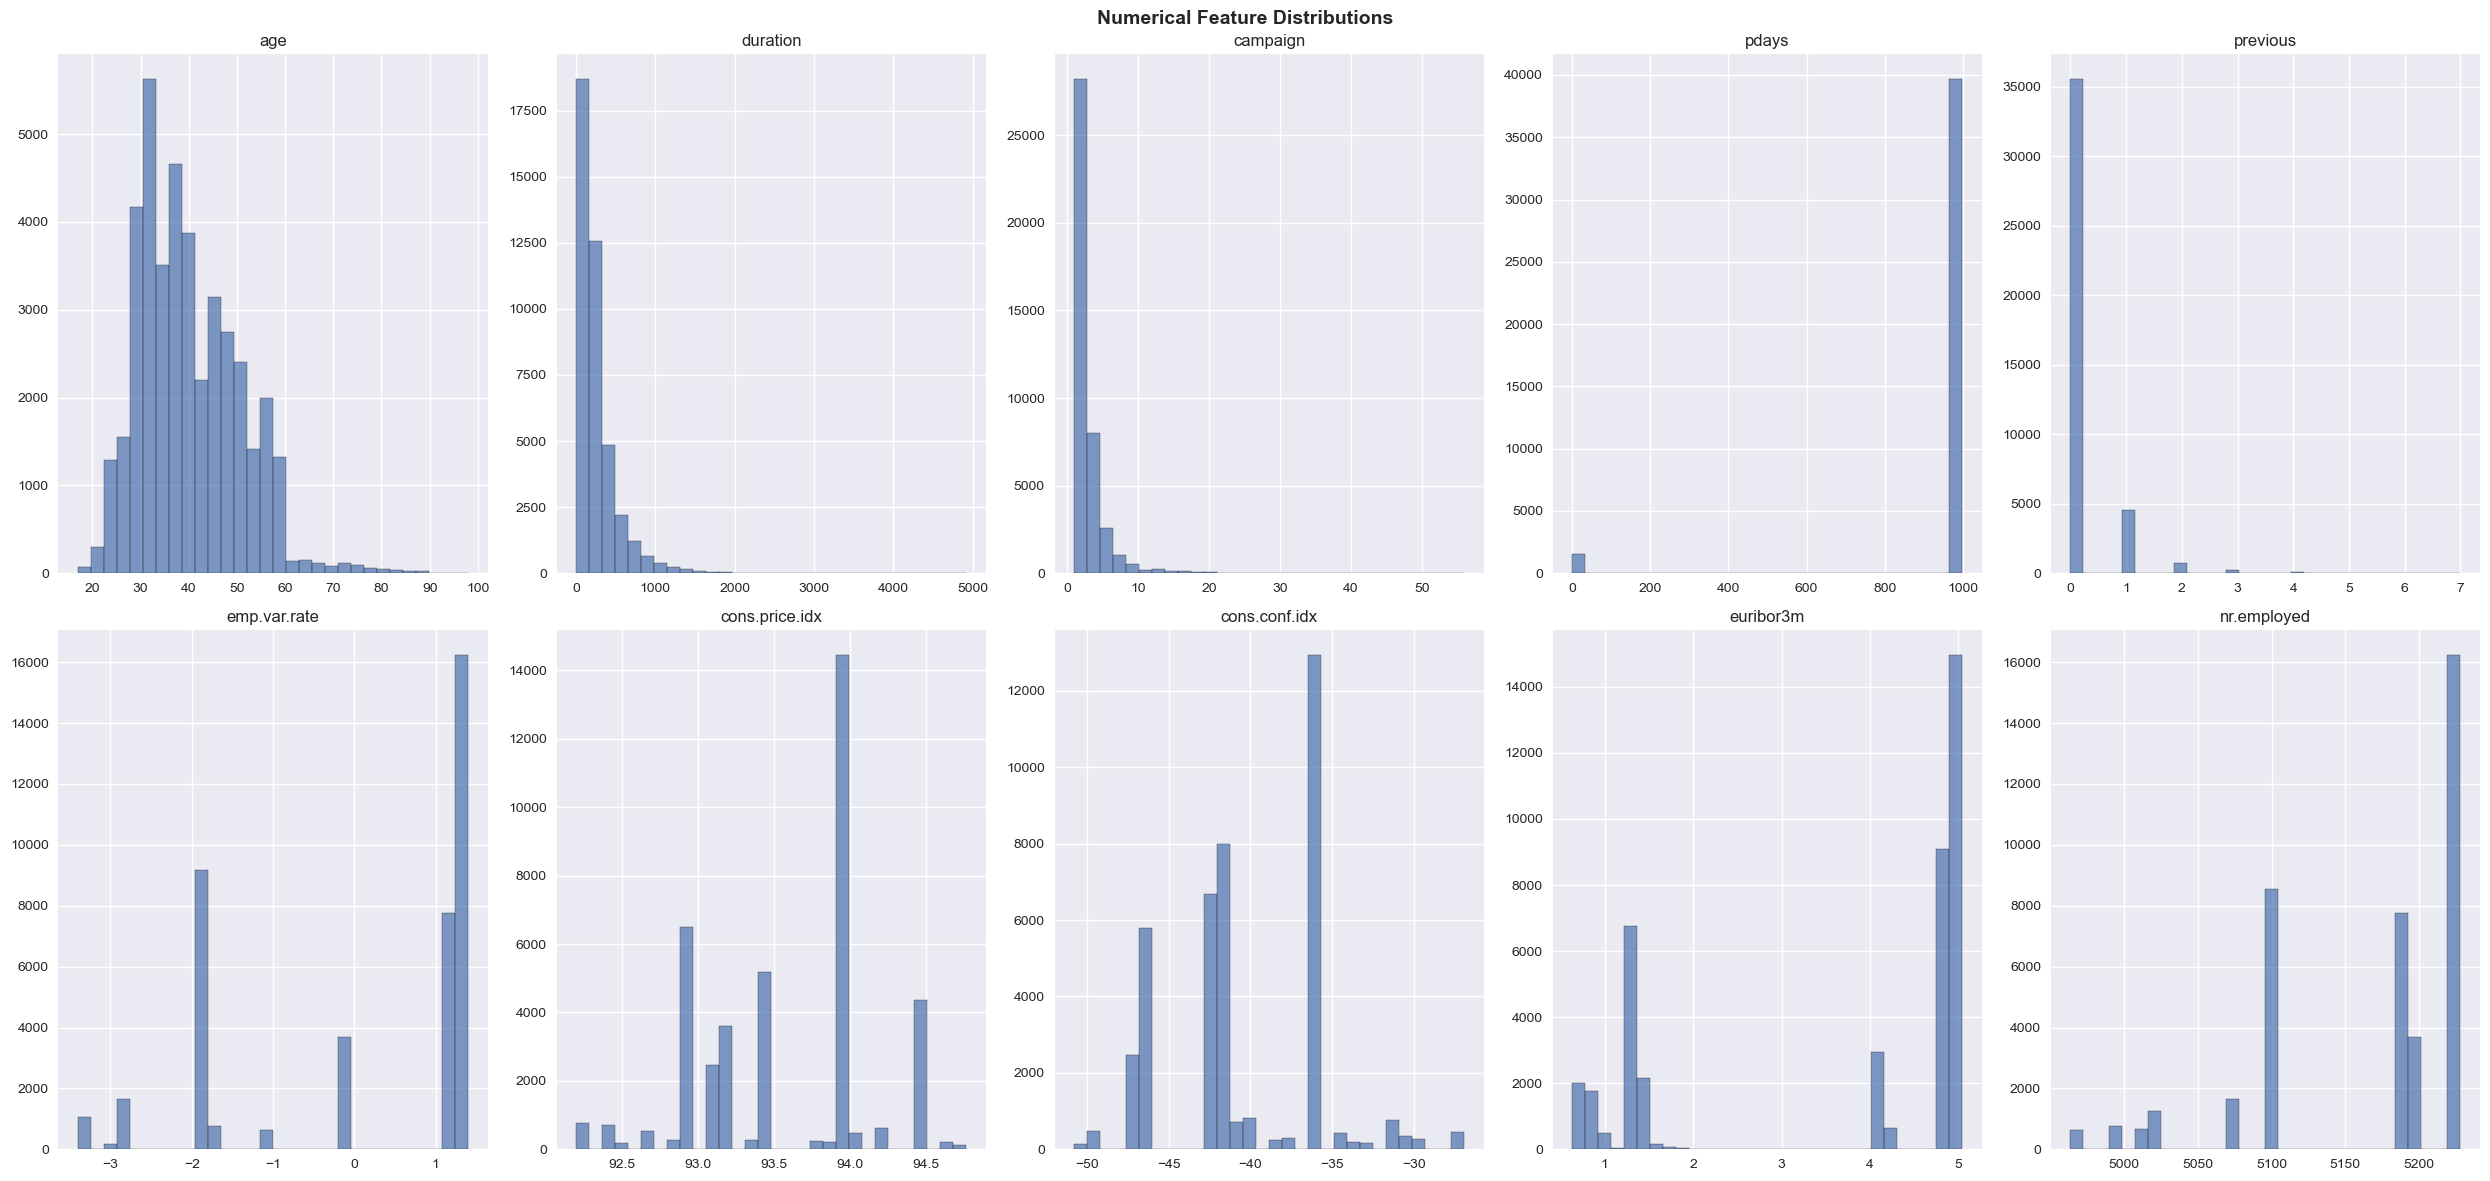

In [26]:
# TODO: histograms for all numerical features





## 5. Explore Categorical Features

In [27]:
## get categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('y')  # remove target
print(f'categorical columns ({len(categorical_cols)}):')
categorical_cols

categorical columns (10):


['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'poutcome']

In [28]:
## value counts for each categorical column
for col in categorical_cols:
    print(f'\n-- {col} ---')
    print(df[col].value_counts())


-- job ---
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

-- marital ---
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

-- education ---
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

-- default ---
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

-- housing ---
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

-- loan ---
loan
no         33950
yes         6248
unknown      990
Nam

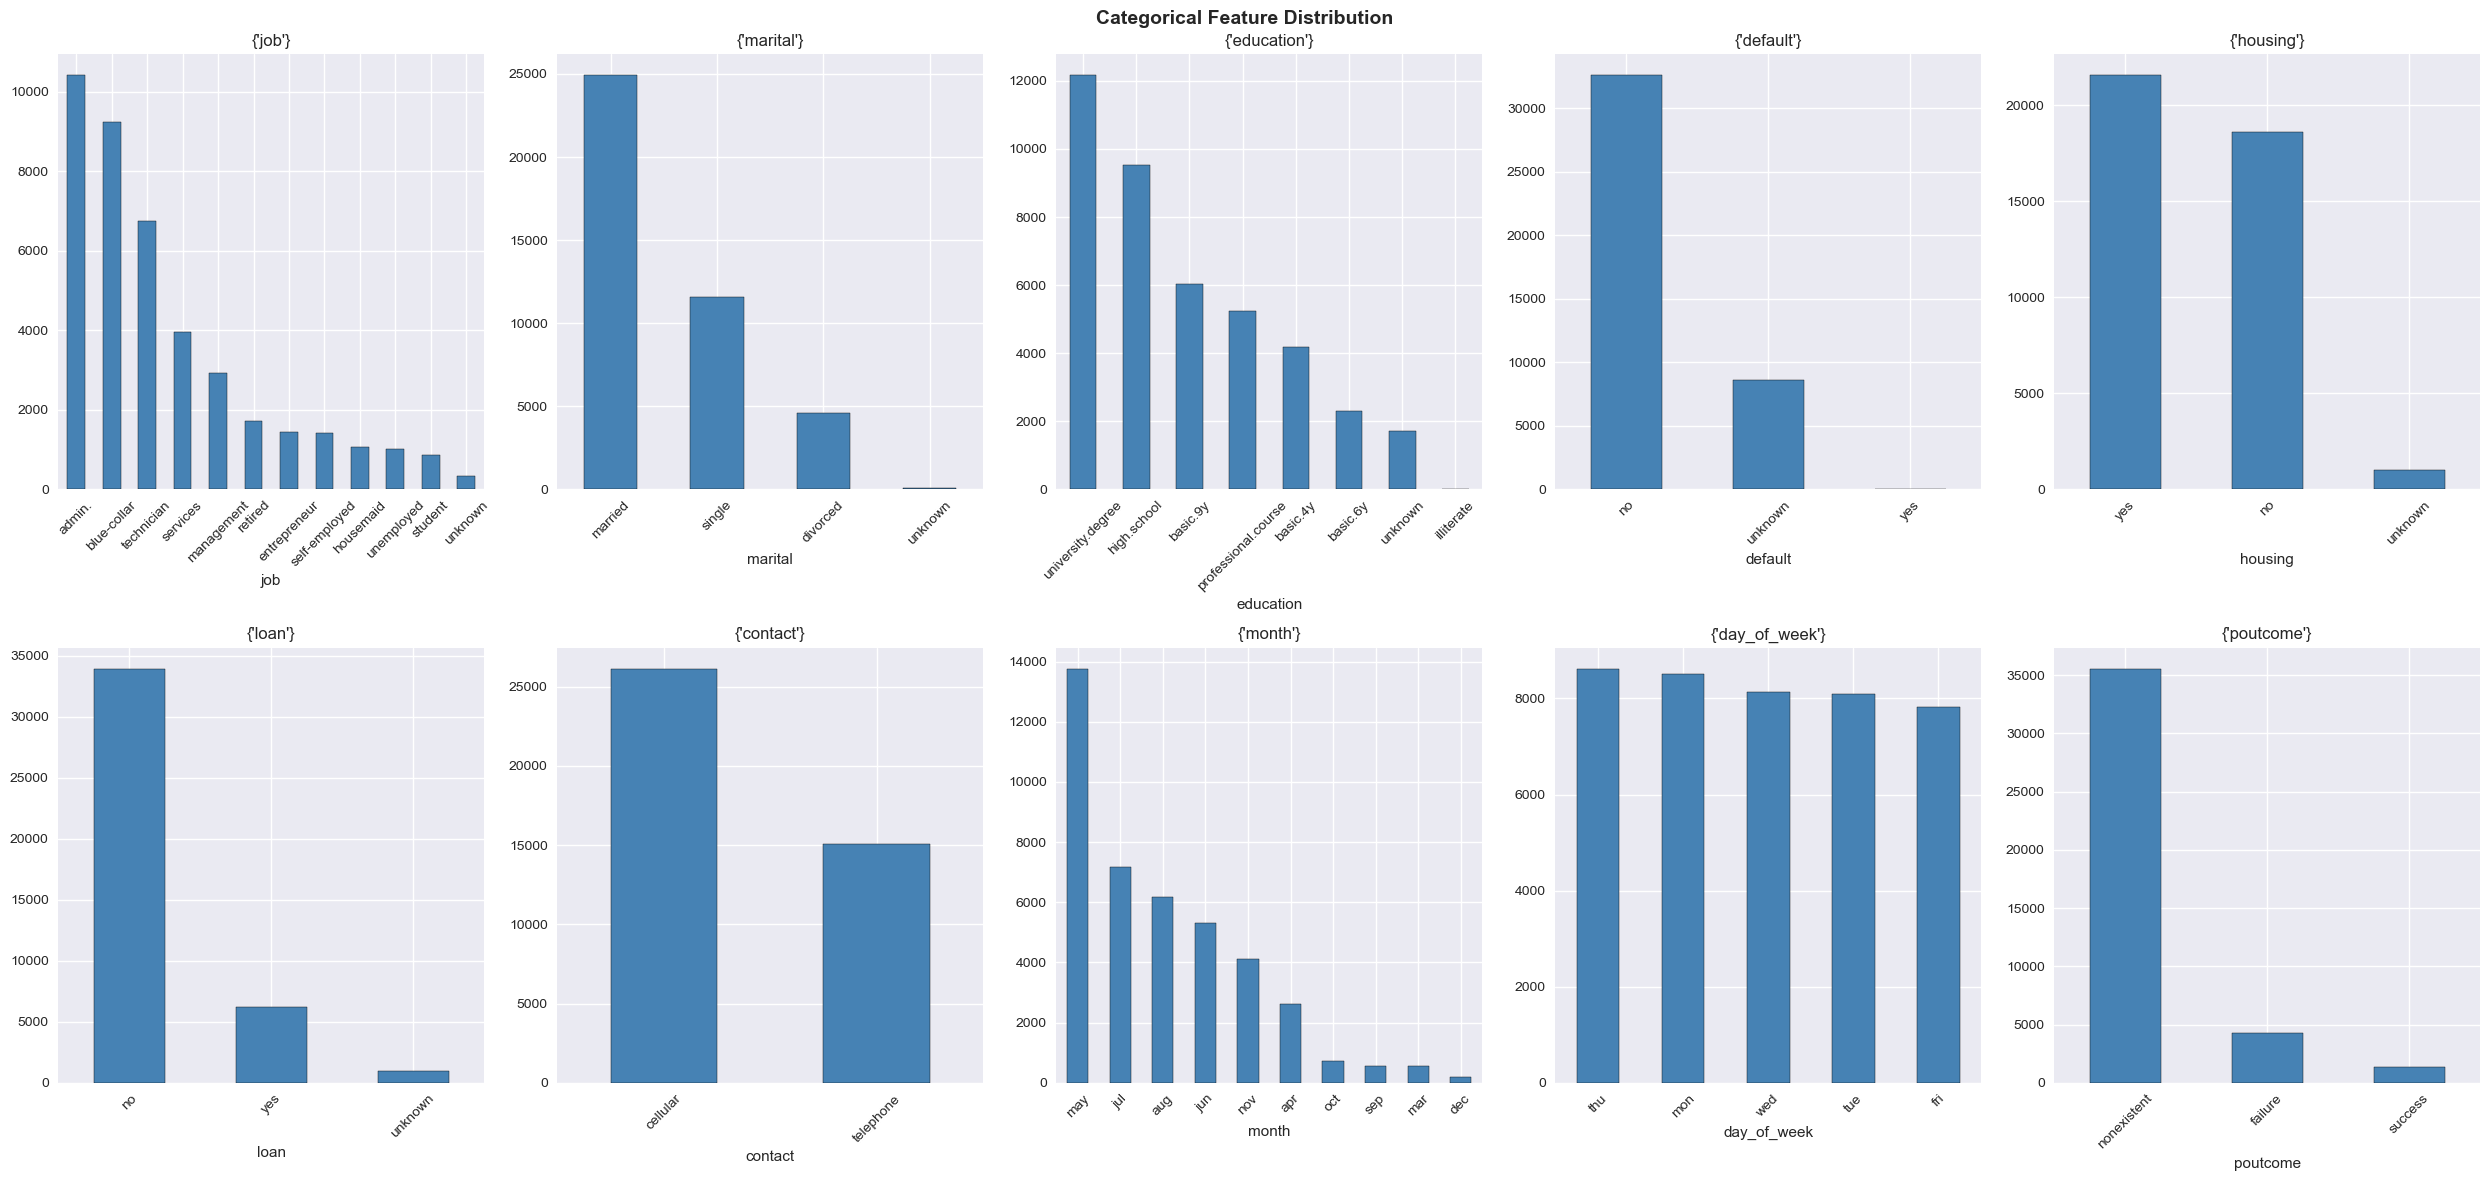

In [29]:
# bar plots for categorical features
fig,axes = plt.subplots(2,5,figsize=(25,12))
axes = axes.flatten()

for i,col in enumerate(categorical_cols):
    
    ## TODO: add bar plot for each categorical column
    df[col].value_counts().plot(kind='bar',ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title({col})
    axes[i].tick_params(axis='x',rotation=45)
    

plt.suptitle('Categorical Feature Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Correlation Analysis

In [30]:
## convert target variable to numeric for correlation

df['y_numeric'] = (df['y']=='yes').astype(int)
df['y_numeric'].value_counts()

y_numeric
0    36548
1     4640
Name: count, dtype: int64

In [31]:
# TODO: Calculate correlation matrix




,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y_numeric
age,1.000000,-0.000866,0.004594,-0.034369,0.024365,-0.000371,0.000857,0.129372,0.010767,-0.017725,0.030399
duration,-0.000866,1.000000,-0.071699,-0.047577,0.020640,-0.027968,0.005312,-0.008173,-0.032897,-0.044703,0.405274
campaign,0.004594,-0.071699,1.000000,0.052584,-0.079141,0.150754,0.127836,-0.013733,0.135133,0.144095,-0.066357
pdays,-0.034369,-0.047577,0.052584,1.000000,-0.587514,0.271004,0.078889,-0.091342,0.296899,0.372605,-0.324914
previous,0.024365,0.020640,-0.079141,-0.587514,1.000000,-0.420489,-0.203130,-0.050936,-0.454494,-0.501333,0.230181
emp.var.rate,-0.000371,-0.027968,0.150754,0.271004,-0.420489,1.000000,0.775334,0.196041,0.972245,0.906970,-0.298334
cons.price.idx,0.000857,0.005312,0.127836,0.078889,-0.203130,0.775334,1.000000,0.058986,0.688230,0.522034,-0.136211
cons.conf.idx,0.129372,-0.008173,-0.013733,-0.091342,-0.050936,0.196041,0.058986,1.000000,0.277686,0.100513,0.054878
euribor3m,0.010767,-0.032897,0.135133,0.296899,-0.454494,0.972245,0.688230,0.277686,1.000000,0.945154,-0.307771
nr.employed,-0.017725,-0.044703,0.144095,0.372605,-0.501333,0.906970,0.522034,0.100513,0.945154,1.000000,-0.354678


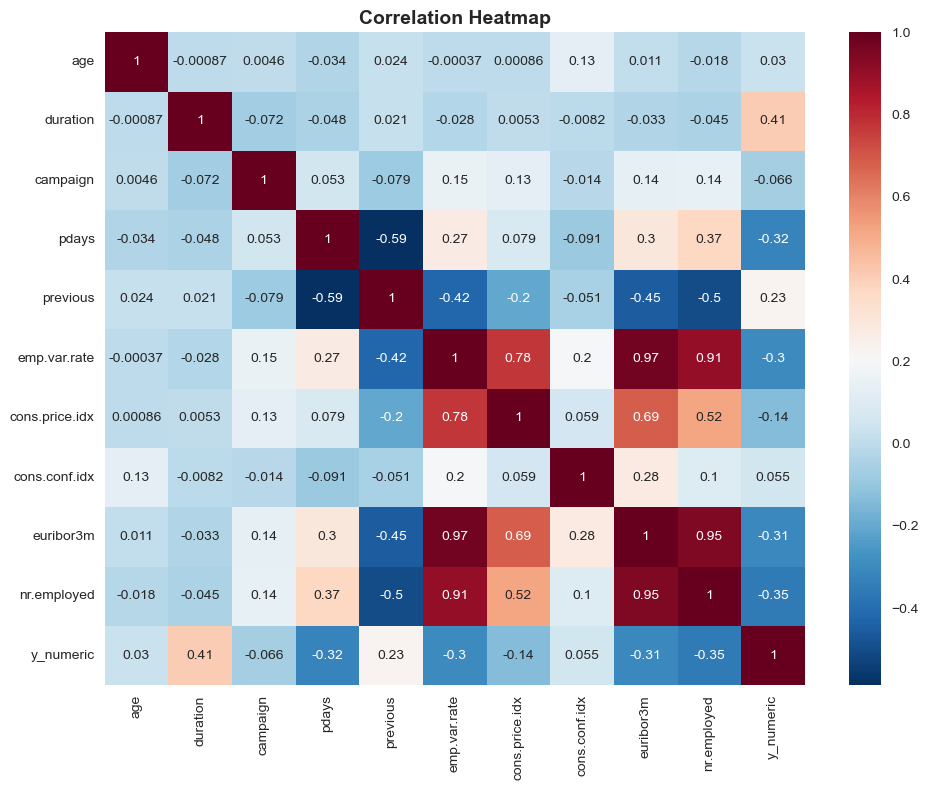

In [32]:
## TODO: correlation heatmap plot





In [33]:
correlation_matrix['y_numeric']

age               0.030399
duration          0.405274
campaign         -0.066357
pdays            -0.324914
previous          0.230181
emp.var.rate     -0.298334
cons.price.idx   -0.136211
cons.conf.idx     0.054878
euribor3m        -0.307771
nr.employed      -0.354678
y_numeric         1.000000
Name: y_numeric, dtype: float64

In [34]:
# Show correlations with target in ascending order
print("Correlations with Target (y):")
correlation_matrix['y_numeric'].sort_values(ascending=True)


Correlations with Target (y):


nr.employed      -0.354678
pdays            -0.324914
euribor3m        -0.307771
emp.var.rate     -0.298334
cons.price.idx   -0.136211
campaign         -0.066357
age               0.030399
cons.conf.idx     0.054878
previous          0.230181
duration          0.405274
y_numeric         1.000000
Name: y_numeric, dtype: float64

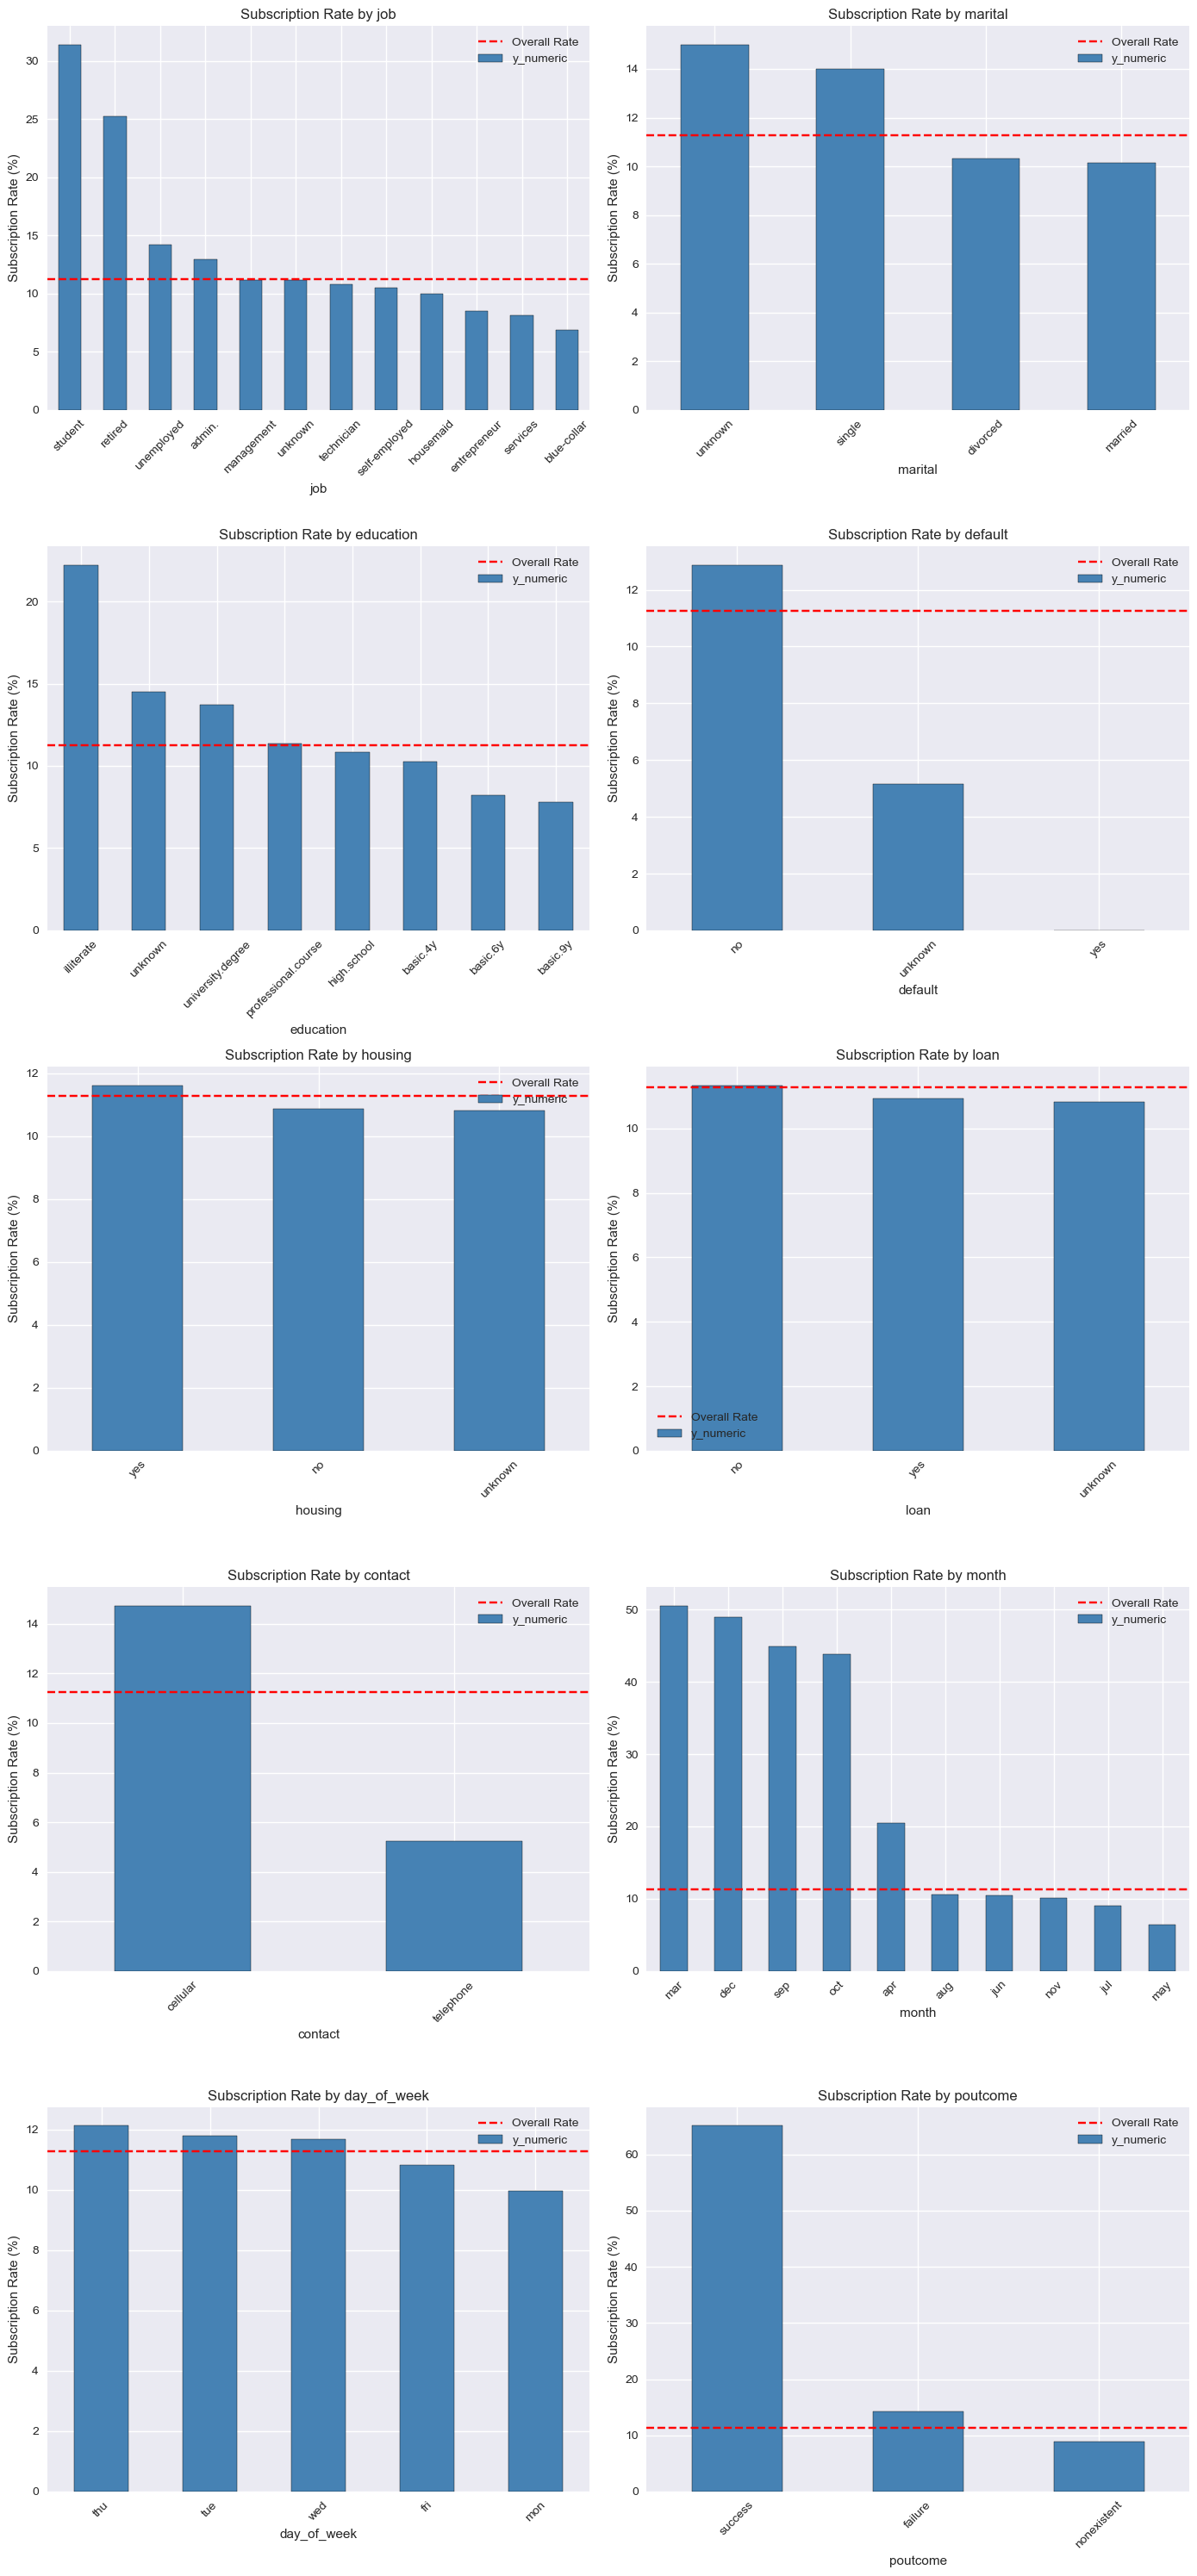

In [35]:
## subscription rate by categorical features

fig, axes = plt.subplots(5, 2, figsize=(14, 30))

for ax, col in zip(axes.flatten(), categorical_cols):
    rate = df.groupby(col)['y_numeric'].mean().sort_values(ascending=False) * 100
    rate.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.axhline(y=df['y_numeric'].mean() * 100, color='red', linestyle='--', label='Overall Rate')
    ax.set_title(f'Subscription Rate by {col}')
    ax.set_ylabel('Subscription Rate (%)')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()

plt.tight_layout()
plt.show()

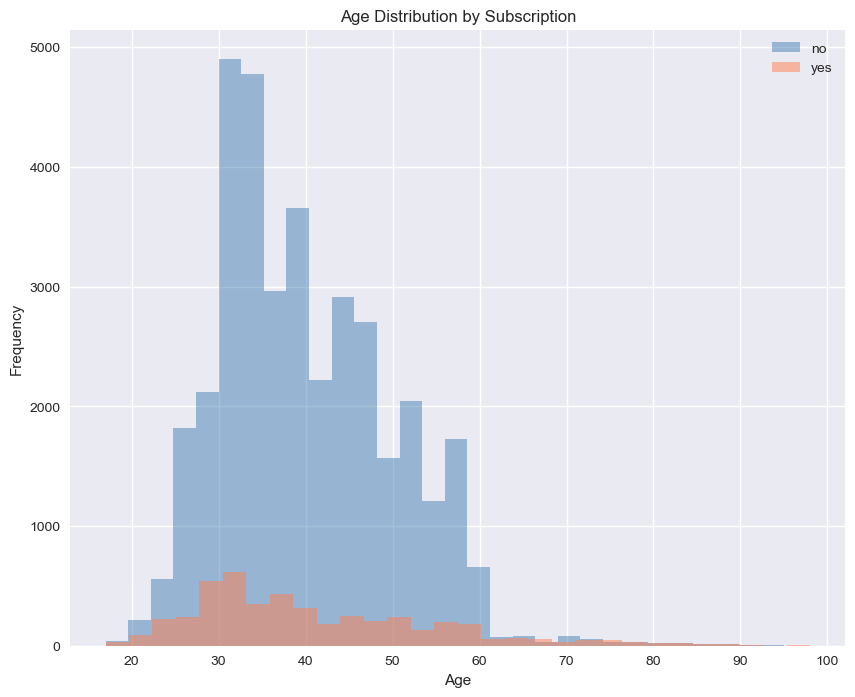

In [36]:
## age distribution by subscription status
plt.figure(figsize=(10,8))
df[df['y']=='no']['age'].hist(bins=30, alpha=0.5, label ='no', color='steelblue')
df[df['y']=='yes']['age'].hist(bins=30, alpha=0.5, label ='yes', color='coral')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution by Subscription')
plt.legend()
plt.show()

## 7. Identify Outliers

In [37]:
# Function to count outliers using IQR method

def count_outlier(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR
    outliers = df[(df[column]<lower_bound)|(df[column]>upper_bound)]
    return len(outliers)

In [38]:
## compute outlier percentage for each numerical feature

for col in numerical_cols:
    n_outliers = count_outlier(col)
    percent = (n_outliers/len(df)) *100
    print(f'{col}: {n_outliers} outliers ({percent:.2f}%)')


age: 469 outliers (1.14%)
duration: 2963 outliers (7.19%)
campaign: 2406 outliers (5.84%)
pdays: 1515 outliers (3.68%)
previous: 5625 outliers (13.66%)
emp.var.rate: 0 outliers (0.00%)
cons.price.idx: 0 outliers (0.00%)
cons.conf.idx: 447 outliers (1.09%)
euribor3m: 0 outliers (0.00%)
nr.employed: 0 outliers (0.00%)


## 8. Data Leakage Detection

**Data leakage** = using information that wouldn't be available at prediction time.

In [39]:
# look at duration by subscription status
df.groupby('y')['duration'].value_counts()

y    duration
no   85          168
     90          168
     73          166
     72          161
     124         160
                ... 
yes  3094          1
     3183          1
     3631          1
     3643          1
     4199          1
Name: count, Length: 2562, dtype: int64

In [40]:
df.groupby('y')['duration'].describe()

,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
no,36548.0,220.844807,207.096293,0.0,95.0,163.5,279.00,4918.0
yes,4640.0,553.191164,401.171871,37.0,253.0,449.0,741.25,4199.0


<Figure size 800x600 with 0 Axes>

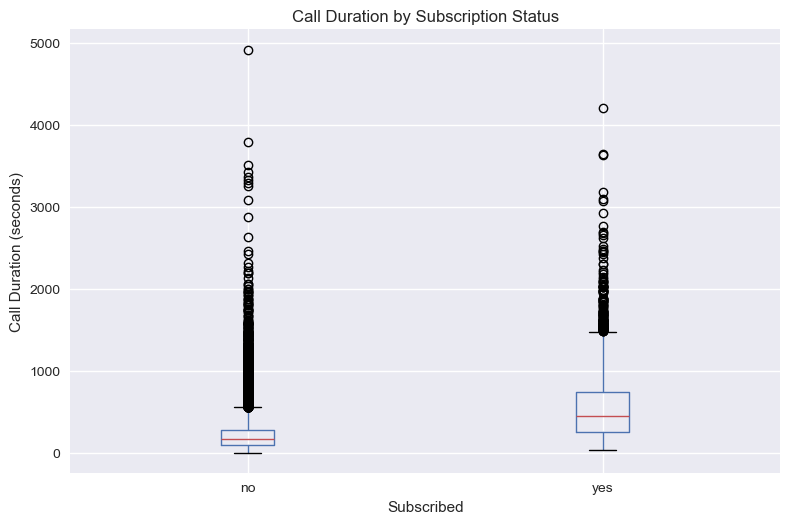

In [41]:
# boxplot: duration vs subscription
plt.figure(figsize=(8,6))
df.boxplot(column='duration',by='y')

plt.xlabel('Subscribed')
plt.ylabel('Call Duration (seconds)')
plt.title('Call Duration by Subscription Status')
plt.suptitle('')  # remove auto title

plt.tight_layout()
plt.show()

In [42]:
## correlation of duration with target

corr = df['duration'].corr(df['y_numeric'])
print(f'Correlation between duration and subscription: {corr:.4f}')
print('This is suspiciously high — a sign of data leakage!')

Correlation between duration and subscription: 0.4053
This is suspiciously high — a sign of data leakage!


**Why `duration` causes data leakage**

- `duration` = how long the phone call lasted
- But we only know this **after** the call ends!
- At prediction time (before calling), duration is unknown
- Longer calls → client was interested → higher subscription

**Strategy: We must REMOVE `duration` before modeling!**

In [43]:
# clean up: drop helper column

df = df.drop('y_numeric', axis=1)

## 9. Key Finding Summary

1. **Dataset:** 
2. **Target(y):** 
3. **Data Leakage:** 
4. **Strong Preditors:** 
5. **Outliers:** 

## Next Step

- Preprocessing (handle unknowns, encode categoricals, remove duration, address class imbalance)

---
## Save Data for Next Notebook

In [44]:
# Save to CSV
df.to_csv('../data/raw/bank_marketing.csv', index=False)
print("Data saved to data/raw/bank_marketing.csv")

Data saved to data/raw/bank_marketing.csv
